# Compare YOLO26-seg — Cross-Validation (`cv_v1`)

## 0. Objetivo e contexto

Esta análise consolida os resultados de **K-fold cross-validation** (k=5, seed=0) aplicado
sobre os cinco scales do YOLO26-seg no ISIC 2018 Task 1. Diferente do notebook
`yolo26_ft_isic_2018_task_1_compare_models.ipynb` — que comparou versões e tamanhos em um
único split fixo train/val — aqui o objetivo é **medir a confiabilidade das métricas** que
reportamos para os orientadores:

> "O `small` chegou a `0.7368` no single-split. Esse número é **representativo da população**
> de imagens ou é um artefato do split escolhido?"

A CV responde isso. Para cada scale, treinamos 5 modelos independentes (cada um com 4/5 do
pool train+val como treino e 1/5 como validação, sem sobreposição), e reportamos `mean ± std`
de cada métrica. O **coeficiente de variação** (`CV = std / mean`) mede o quanto cada
métrica oscila entre folds — um CV baixo (~1%) é evidência forte de robustez.

### Pipeline

```
hpo_v3/tune_isic_2018_task_1_<scale>/best_hyperparameters.yaml  →  best HP por scale
                                                                 ↓
           train_all_models_cv.py  →  5 treinos × 5 scales = 25 modelos
                                                                 ↓
                                  metrics_per_fold.csv  (1 linha por fold)
                                  metrics_summary.json  (mean ± std consolidados)
                                  runs/fold_<k>/results.csv  (curvas por época)
```

### O que este notebook entrega

| Seção | Pergunta que responde |
|-------|------------------------|
| §4    | "Quais são os números finais consolidados (mean ± CI95) por scale?" |
| §5-7  | "Como as métricas variam entre folds?" (bars + boxplot + strip) |
| §8    | "Qual scale é o mais estável? Qual a métrica mais sensível ao split?" |
| §9    | "Quando o `best.pt` é selecionado em cada fold? Há convergência consistente?" |
| §10-11 | "As curvas de treino batem entre folds? Há overfitting em algum fold específico?" |
| §13   | "A scaling law (mAP × params) se mantém com erro estimado?" |
| §14   | "Qual o trade-off mAP × custo de treino, considerando que CV multiplica custo por k?" |
| §15   | "Os hp efetivamente aplicados em cada scale conferem com o `best_hyperparameters.yaml`?" |
| §16   | "Insights automáticos: champion global, mais estável, melhor custo-benefício." |
| §17   | "O resultado single-split anterior está dentro do envelope CV?" |

> O notebook é **tolerante a resultados parciais**: se apenas o `small` finalizou, ele roda
> normalmente e marca os demais como `[MISSING]`. Adicione novos scales/versões em §1.1.


## 1. Setup

In [22]:
import json
import warnings
from pathlib import Path
from typing import Iterable

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from IPython.display import display, Markdown
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=FutureWarning)

# ----- estilo global ---------------------------------------------------------
plt.style.use("seaborn-v0_8-whitegrid")
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "legend.fontsize": 10,
})
sns.set_context("notebook", font_scale=1.0)

# ----- paleta por scale (Okabe-Ito) ------------------------------------------
MODEL_PALETTE = {
    "Nano":   "#56B4E9",
    "Small":  "#0072B2",
    "Medium": "#009E73",
    "Large":  "#E69F00",
    "XLarge": "#D55E00",
}

# ----- paleta por versão CV (cv_v1 primeiro; estensível) ---------------------
VERSION_PALETTE = {
    "cv_v1": "#112BD7",
    "cv_v2": "#D55E00",
    "cv_v3": "#009E73",
}

# Specs nominais YOLO26-seg
MODEL_SPECS = {
    "Nano":   {"params_m":  3.4, "gflops":  10.4},
    "Small":  {"params_m": 11.4, "gflops":  37.1},
    "Medium": {"params_m": 25.9, "gflops":  98.9},
    "Large":  {"params_m": 43.7, "gflops": 165.7},
    "XLarge": {"params_m": 68.2, "gflops": 257.8},
}

MODEL_ORDER_FULL = ["Nano", "Small", "Medium", "Large", "XLarge"]
SCALE_KEY_LOWER = {m: m.lower() for m in MODEL_ORDER_FULL}

SUCCESS = "#2A9D8F"
DANGER  = "#E63946"
NEUTRAL = "#6C757D"

# ----- métricas de interesse (chaves no metrics_per_fold.csv) ----------------
METRIC_KEYS_MASK = ["map5095_m", "map50_m", "f1_m", "precision_m", "recall_m"]
METRIC_KEYS_BOX  = ["map5095_b", "map50_b", "f1_b", "precision_b", "recall_b"]
METRIC_KEYS_ALL  = METRIC_KEYS_MASK + METRIC_KEYS_BOX

# Rótulos amigáveis pra tabelas/legenda
METRIC_LABEL = {
    "map5095_m":   "Mask mAP@50-95",
    "map50_m":     "Mask mAP@50",
    "f1_m":        "Mask F1",
    "precision_m": "Mask Precision",
    "recall_m":    "Mask Recall",
    "map5095_b":   "BBox mAP@50-95",
    "map50_b":     "BBox mAP@50",
    "f1_b":        "BBox F1",
    "precision_b": "BBox Precision",
    "recall_b":    "BBox Recall",
    "best_epoch":  "Best epoch",
}

# t-Student crítico para CI95% com df = k - 1
T_CRIT_95 = {2: 12.706, 3: 4.303, 4: 3.182, 5: 2.776,
             6: 2.571,  7: 2.447, 8: 2.365, 9: 2.306, 10: 2.262}


### 1.1 Configuração principal

Cada chave de `CV_VERSIONS` aponta para um diretório `<log_dir>` que contém uma pasta
`yolo26_<scale>_cv_isic_2018/` com os arquivos:

- `metrics_per_fold.csv` — uma linha por fold (campos `best_epoch`, `f1_m`, `map5095_m`, …);
- `metrics_summary.json` — dict consolidado com `per_fold[]` + `summary{mean,std}`;
- `runs/fold_<k>/results.csv` — opcional, fornece curvas por época para §10-§12.

Comente as linhas correspondentes para desativar scales/versões.


In [44]:
# Mude `unb_server` conforme o ambiente.
unb_server = True

if unb_server:
    BASE_DIR = Path("/home/antoniovinicius/projects/sandbox_yolo26")
else:
    BASE_DIR = Path("/home/avmoura_linux/Documents/unb/sandbox_yolo26")

CV_VERSIONS = {
    "cv_v1": {
        "log_dir": BASE_DIR / "logs" / "cv" / "cv_v1",
        "model_dirs": {
            "Nano":   "yolo26_nano_cv_isic_2018",
            "Small":  "yolo26_small_cv_isic_2018",
            "Medium": "yolo26_medium_cv_isic_2018",
            "Large":  "yolo26_large_cv_isic_2018",
            "XLarge": "yolo26_xlarge_cv_isic_2018",
        },
    },
}

VERSION_ORDER = list(CV_VERSIONS.keys())

# Sanity check de paths
print(f"{'Version':<8}{'Model':<8}{'Status':<14}Path")
print("-" * 100)
for v, cfg in CV_VERSIONS.items():
    for m in MODEL_ORDER_FULL:
        if m not in cfg["model_dirs"]:
            continue
        p = cfg["log_dir"] / cfg["model_dirs"][m]
        if not p.exists():
            status = "[MISSING]"
        else:
            has_summary = (p / "metrics_per_fold.csv").exists()
            has_curves = any((p / "runs" / f"fold_{k}" / "results.csv").exists()
                              for k in range(20))
            if has_summary and has_curves:
                status = "[OK full]"
            elif has_summary:
                status = "[OK summary]"
            else:
                status = "[OK no metr]"
        print(f"{v:<8}{m:<8}{status:<14}{p}")


Version Model   Status        Path
----------------------------------------------------------------------------------------------------
cv_v1   Nano    [OK no metr]  /home/antoniovinicius/projects/sandbox_yolo26/logs/cv/cv_v1/yolo26_nano_cv_isic_2018
cv_v1   Small   [OK full]     /home/antoniovinicius/projects/sandbox_yolo26/logs/cv/cv_v1/yolo26_small_cv_isic_2018
cv_v1   Medium  [MISSING]     /home/antoniovinicius/projects/sandbox_yolo26/logs/cv/cv_v1/yolo26_medium_cv_isic_2018
cv_v1   Large   [MISSING]     /home/antoniovinicius/projects/sandbox_yolo26/logs/cv/cv_v1/yolo26_large_cv_isic_2018
cv_v1   XLarge  [MISSING]     /home/antoniovinicius/projects/sandbox_yolo26/logs/cv/cv_v1/yolo26_xlarge_cv_isic_2018


## 2. Helpers

In [24]:
def smooth(x: np.ndarray, window: int = 5) -> np.ndarray:
    """Centered moving average (NaN-safe)."""
    s = pd.Series(x).rolling(window=window, center=True, min_periods=1).mean()
    return s.to_numpy()


def ci95_halfwidth(values: Iterable[float]) -> float:
    """Half-width do intervalo de confiança 95% (t-Student) para k folds."""
    arr = np.asarray(list(values), dtype=float)
    arr = arr[~np.isnan(arr)]
    n = len(arr)
    if n < 2:
        return float("nan")
    std = arr.std(ddof=1)
    t = T_CRIT_95.get(n, 1.96)
    return float(t * std / np.sqrt(n))


def mean_std_str(mean: float, std: float, prec: int = 4) -> str:
    if not np.isfinite(mean):
        return "—"
    if not np.isfinite(std):
        return f"{mean:.{prec}f}"
    return f"{mean:.{prec}f} ± {std:.{prec}f}"


def mean_ci_str(mean: float, ci: float, prec: int = 4) -> str:
    if not np.isfinite(mean):
        return "—"
    if not np.isfinite(ci):
        return f"{mean:.{prec}f}"
    return f"{mean:.{prec}f} ± {ci:.{prec}f}"


def epochs_to_threshold(df: pd.DataFrame, col: str, frac: float = 0.95) -> int | float:
    if col not in df or df[col].dropna().empty:
        return np.nan
    target = df[col].max() * frac
    hit = df.loc[df[col] >= target, "epoch"]
    if hit.empty:
        return np.nan
    return int(hit.iloc[0])


def stability(df: pd.DataFrame, col: str, last_n: int = 10) -> float:
    if col not in df:
        return np.nan
    s = df[col].dropna().tail(last_n)
    return float(s.std(ddof=0)) if not s.empty else np.nan


def overfit_gap(df: pd.DataFrame, best_idx: int, train_col: str,
                val_col: str) -> float:
    try:
        return float(df.loc[best_idx, val_col] - df.loc[best_idx, train_col])
    except (KeyError, IndexError):
        return np.nan


## 3. Carga de dados

Para cada `(version, scale)` montamos dois objetos:

- `summary_row` — uma linha por combinação `(version, scale)` com `mean`, `std`, `ci95`, e
  estatísticas auxiliares (best_epoch mean, train time total / fold);
- `fold_rows` — uma linha por fold (5 por combinação), preserva o valor bruto de cada
  métrica para boxplots e CI bootstrap se necessário.

Curvas por época (em `runs/fold_<k>/results.csv`) são carregadas só quando o diretório
existe — caso contrário §10-§12 reportam o que tem.

In [25]:
def _load_fold_results(results_dir: Path) -> dict[int, pd.DataFrame]:
    """Lê `runs/fold_<k>/results.csv` para cada fold disponível."""
    out: dict[int, pd.DataFrame] = {}
    runs_dir = results_dir / "runs"
    if not runs_dir.exists():
        return out
    for fold_dir in sorted(runs_dir.iterdir()):
        if not fold_dir.is_dir() or not fold_dir.name.startswith("fold_"):
            continue
        rcsv = fold_dir / "results.csv"
        if not rcsv.exists():
            continue
        try:
            k = int(fold_dir.name.split("_", 1)[1])
        except ValueError:
            continue
        df = pd.read_csv(rcsv)
        df.columns = [c.strip() for c in df.columns]
        out[k] = df
    return out


def _load_fold_args(results_dir: Path) -> dict:
    """Lê `runs/fold_0/args.yaml` como representante (mesmos hp em todos os folds)."""
    p = results_dir / "runs" / "fold_0" / "args.yaml"
    if not p.exists():
        return {}
    try:
        return yaml.safe_load(p.read_text()) or {}
    except yaml.YAMLError:
        return {}


def extract_cv_summary(version: str, model_name: str, results_dir: Path
                       ) -> dict | None:
    """Lê metrics_per_fold + metrics_summary + curvas por fold (opcional).
    Retorna None se nenhum artefato mínimo existir.
    """
    if not results_dir.exists():
        return None

    per_fold_csv = results_dir / "metrics_per_fold.csv"
    summary_json = results_dir / "metrics_summary.json"

    if not per_fold_csv.exists() and not summary_json.exists():
        return None

    per_fold = pd.read_csv(per_fold_csv) if per_fold_csv.exists() else pd.DataFrame()
    summary = json.loads(summary_json.read_text()) if summary_json.exists() else {}

    fold_dfs = _load_fold_results(results_dir)
    args = _load_fold_args(results_dir)

    # Métricas brutas por fold (lista de dicts) — preferimos o per_fold_csv (mais fiel).
    if not per_fold.empty:
        fold_records = per_fold.to_dict(orient="records")
    else:
        fold_records = summary.get("per_fold", [])

    # Sumário consolidado (mean/std) — preferimos o JSON (calculado pelo orchestrador).
    summary_dict = summary.get("summary")
    if not summary_dict and fold_records:
        # Recalcula a partir do per_fold_csv como fallback.
        keys = [k for k in fold_records[0] if k != "fold"]
        summary_dict = {}
        for k in keys:
            vals = [r[k] for r in fold_records if k in r]
            summary_dict[k] = {
                "mean": float(np.mean(vals)) if vals else np.nan,
                "std":  float(np.std(vals, ddof=0)) if vals else np.nan,
            }

    # Tempo total de treino: soma do max(time) de cada results.csv (em min).
    train_time_per_fold = []
    stability_per_fold = []
    overfit_gap_per_fold = []
    eps_to_95_per_fold = []
    eps_to_99_per_fold = []
    for _, df in fold_dfs.items():
        if "time" in df:
            train_time_per_fold.append(float(df["time"].max()) / 60.0)
        if "metrics/mAP50-95(M)" in df:
            stability_per_fold.append(stability(df, "metrics/mAP50-95(M)", 10))
            eps_to_95_per_fold.append(epochs_to_threshold(df, "metrics/mAP50-95(M)", 0.95))
            eps_to_99_per_fold.append(epochs_to_threshold(df, "metrics/mAP50-95(M)", 0.99))
        if "metrics/mAP50-95(M)" in df and "train/seg_loss" in df and "val/seg_loss" in df:
            best_idx = df["metrics/mAP50-95(M)"].idxmax()
            overfit_gap_per_fold.append(
                overfit_gap(df, best_idx, "train/seg_loss", "val/seg_loss")
            )

    # Linha consolidada (uma por version × scale).
    row = {
        "Version": version,
        "Model":   model_name,
        "Params (M)": MODEL_SPECS.get(model_name, {}).get("params_m", np.nan),
        "GFLOPs":     MODEL_SPECS.get(model_name, {}).get("gflops",   np.nan),
        "k_folds":    len(fold_records),
        "_summary":   summary_dict or {},
        "_fold_records": fold_records,
        "_fold_dfs":  fold_dfs,
        "_args":      args,
        "_results_dir": results_dir,
        # tempos consolidados
        "Train time / fold (min)": float(np.mean(train_time_per_fold))
                                    if train_time_per_fold else np.nan,
        "Train time total (min)":  float(np.sum(train_time_per_fold))
                                    if train_time_per_fold else np.nan,
        "Stability (avg std last10)": float(np.mean(stability_per_fold))
                                       if stability_per_fold else np.nan,
        "Overfit gap (avg)":          float(np.mean(overfit_gap_per_fold))
                                       if overfit_gap_per_fold else np.nan,
        "Eps to 95% (avg)":           float(np.mean(eps_to_95_per_fold))
                                       if eps_to_95_per_fold else np.nan,
        "Eps to 99% (avg)":           float(np.mean(eps_to_99_per_fold))
                                       if eps_to_99_per_fold else np.nan,
    }

    # Achata `summary_dict` em colunas planas para queries rápidas (mean/std/ci95).
    for k, stats in (summary_dict or {}).items():
        mean = stats.get("mean", np.nan)
        std  = stats.get("std",  np.nan)
        row[f"{k}_mean"] = mean
        row[f"{k}_std"]  = std
        vals = [r.get(k) for r in fold_records if r.get(k) is not None]
        row[f"{k}_ci95"] = ci95_halfwidth(vals) if len(vals) >= 2 else np.nan
        row[f"{k}_cv"]   = (std / mean) if (mean and np.isfinite(mean) and mean != 0
                                            and np.isfinite(std)) else np.nan

    return row


# Loop versions × scales
rows = []
fold_rows = []
missing = []
for v, cfg in CV_VERSIONS.items():
    for m in MODEL_ORDER_FULL:
        if m not in cfg["model_dirs"]:
            continue
        rdir = cfg["log_dir"] / cfg["model_dirs"][m]
        s = extract_cv_summary(v, m, rdir)
        if s is None:
            missing.append((v, m, rdir))
        else:
            rows.append(s)
            for r in s["_fold_records"]:
                fr = {"Version": v, "Model": m, **r}
                fold_rows.append(fr)

if not rows:
    raise FileNotFoundError(
        "Nenhum metrics_per_fold.csv carregado — verifique CV_VERSIONS em §1.1."
    )

df_long = pd.DataFrame(rows)
df_folds = pd.DataFrame(fold_rows)

VERSIONS_PRESENT = [v for v in VERSION_ORDER if v in df_long["Version"].unique()]
MODELS_PRESENT   = [m for m in MODEL_ORDER_FULL if m in df_long["Model"].unique()]

print(f"Carregados: {len(df_long)} combinações ({len(VERSIONS_PRESENT)} versões × "
      f"{len(MODELS_PRESENT)} scales) | total de folds: {len(df_folds)}")
print(f"Versões presentes: {VERSIONS_PRESENT}")
print(f"Scales presentes:  {MODELS_PRESENT}")
if missing:
    print(f"\n[skip] {len(missing)} combinações sem artefatos CV:")
    for v, m, p in missing:
        print(f"  {v:<8}{m:<8}{p}")


Carregados: 1 combinações (1 versões × 1 scales) | total de folds: 5
Versões presentes: ['cv_v1']
Scales presentes:  ['Small']

[skip] 4 combinações sem artefatos CV:
  cv_v1   Nano    /home/antoniovinicius/projects/sandbox_yolo26/logs/cv/cv_v1/yolo26_nano_cv_isic_2018
  cv_v1   Medium  /home/antoniovinicius/projects/sandbox_yolo26/logs/cv/cv_v1/yolo26_medium_cv_isic_2018
  cv_v1   Large   /home/antoniovinicius/projects/sandbox_yolo26/logs/cv/cv_v1/yolo26_large_cv_isic_2018
  cv_v1   XLarge  /home/antoniovinicius/projects/sandbox_yolo26/logs/cv/cv_v1/yolo26_xlarge_cv_isic_2018


## 4. Resumo executivo

**Champion global** = melhor mean(Mask mAP@50-95) entre todas as combinações
`(version, scale)` disponíveis. As tabelas a seguir resumem os números **prontos para
relatório**: `mean ± CI95` (intervalo de confiança 95% via t-Student, df = k-1).

In [26]:
best_row = df_long.loc[df_long["map5095_m_mean"].idxmax()]
display(Markdown(
    f"### 🏆 Champion global (CV): **{best_row['Version']} · {best_row['Model']}**  \n"
    f"Mask mAP@50-95 = **{best_row['map5095_m_mean']:.4f} ± {best_row['map5095_m_ci95']:.4f}** "
    f"(CI95, k={int(best_row['k_folds'])})  \n"
    f"σ entre folds = {best_row['map5095_m_std']:.4f}  ·  "
    f"CV (std/mean) = **{best_row['map5095_m_cv']*100:.2f}%**"
))


display(Markdown("### 4.1 Métricas Mask — mean ± CI95 por scale"))

def _fmt_mean_ci(row, base: str, prec: int = 4) -> str:
    return mean_ci_str(row[f"{base}_mean"], row[f"{base}_ci95"], prec=prec)


tab_mask = pd.DataFrame({
    "Mask mAP@50":    df_long.apply(lambda r: _fmt_mean_ci(r, "map50_m"),   axis=1),
    "Mask mAP@50-95": df_long.apply(lambda r: _fmt_mean_ci(r, "map5095_m"), axis=1),
    "Mask Precision": df_long.apply(lambda r: _fmt_mean_ci(r, "precision_m"), axis=1),
    "Mask Recall":    df_long.apply(lambda r: _fmt_mean_ci(r, "recall_m"),  axis=1),
    "Mask F1":        df_long.apply(lambda r: _fmt_mean_ci(r, "f1_m"),      axis=1),
}, index=pd.MultiIndex.from_arrays(
    [df_long["Version"], df_long["Model"]], names=["Version", "Model"]
))

# Reindexa para mostrar todas as combinações (mesmo as missing) na ordem canônica
full_idx = pd.MultiIndex.from_product([VERSIONS_PRESENT, MODELS_PRESENT],
                                       names=["Version", "Model"])
tab_mask = tab_mask.reindex(full_idx).fillna("—")
display(tab_mask.style.set_caption("Mask — formato: mean ± half-width(CI95)"))


display(Markdown("### 4.2 Métricas BBox — mean ± CI95 por scale"))
tab_box = pd.DataFrame({
    "BBox mAP@50":    df_long.apply(lambda r: _fmt_mean_ci(r, "map50_b"),     axis=1),
    "BBox mAP@50-95": df_long.apply(lambda r: _fmt_mean_ci(r, "map5095_b"),   axis=1),
    "BBox Precision": df_long.apply(lambda r: _fmt_mean_ci(r, "precision_b"), axis=1),
    "BBox Recall":    df_long.apply(lambda r: _fmt_mean_ci(r, "recall_b"),    axis=1),
    "BBox F1":        df_long.apply(lambda r: _fmt_mean_ci(r, "f1_b"),        axis=1),
}, index=pd.MultiIndex.from_arrays(
    [df_long["Version"], df_long["Model"]], names=["Version", "Model"]
)).reindex(full_idx).fillna("—")
display(tab_box.style.set_caption("BBox — formato: mean ± half-width(CI95)"))


display(Markdown("### 4.3 Champion por scale (melhor versão de cada scale por Mask mAP@50-95)"))
champ_per_m = (
    df_long.sort_values("map5095_m_mean", ascending=False)
    .groupby("Model", as_index=False).first()
    .set_index("Model").reindex(MODELS_PRESENT)
)
champ_view = pd.DataFrame({
    "Version":         champ_per_m["Version"],
    "Mask mAP@50-95":  champ_per_m.apply(lambda r: _fmt_mean_ci(r, "map5095_m"), axis=1),
    "Mask mAP@50":     champ_per_m.apply(lambda r: _fmt_mean_ci(r, "map50_m"),   axis=1),
    "Mask F1":         champ_per_m.apply(lambda r: _fmt_mean_ci(r, "f1_m"),      axis=1),
    "Best epoch (avg)": champ_per_m["best_epoch_mean"].apply(
        lambda x: f"{x:.1f}" if np.isfinite(x) else "—"),
    "k":                champ_per_m["k_folds"].apply(
        lambda x: f"{int(x)}" if np.isfinite(x) else "—"),
}).fillna("—")
display(champ_view.style.set_caption("Champion por scale — mean ± CI95"))


### 🏆 Champion global (CV): **cv_v1 · Small**  
Mask mAP@50-95 = **0.7372 ± 0.0072** (CI95, k=5)  
σ entre folds = 0.0052  ·  CV (std/mean) = **0.70%**

### 4.1 Métricas Mask — mean ± CI95 por scale

,,Mask mAP@50,Mask mAP@50-95,Mask Precision,Mask Recall,Mask F1
Version,Model,,,,,
cv_v1,Small,—,—,—,—,—


### 4.2 Métricas BBox — mean ± CI95 por scale

,,BBox mAP@50,BBox mAP@50-95,BBox Precision,BBox Recall,BBox F1
Version,Model,,,,,
cv_v1,Small,—,—,—,—,—


### 4.3 Champion por scale (melhor versão de cada scale por Mask mAP@50-95)

,Version,Mask mAP@50-95,Mask mAP@50,Mask F1,Best epoch (avg),k
Model,,,,,,
Small,cv_v1,0.7372 ± 0.0072,0.9703 ± 0.0054,0.9543 ± 0.0069,94.4,5


## 5. Performance principal — mean ± std (com error bars)

Barras agrupadas com **error bars** (1 σ entre folds). Diferente do notebook
single-split, aqui cada barra carrega a incerteza estimada da métrica.

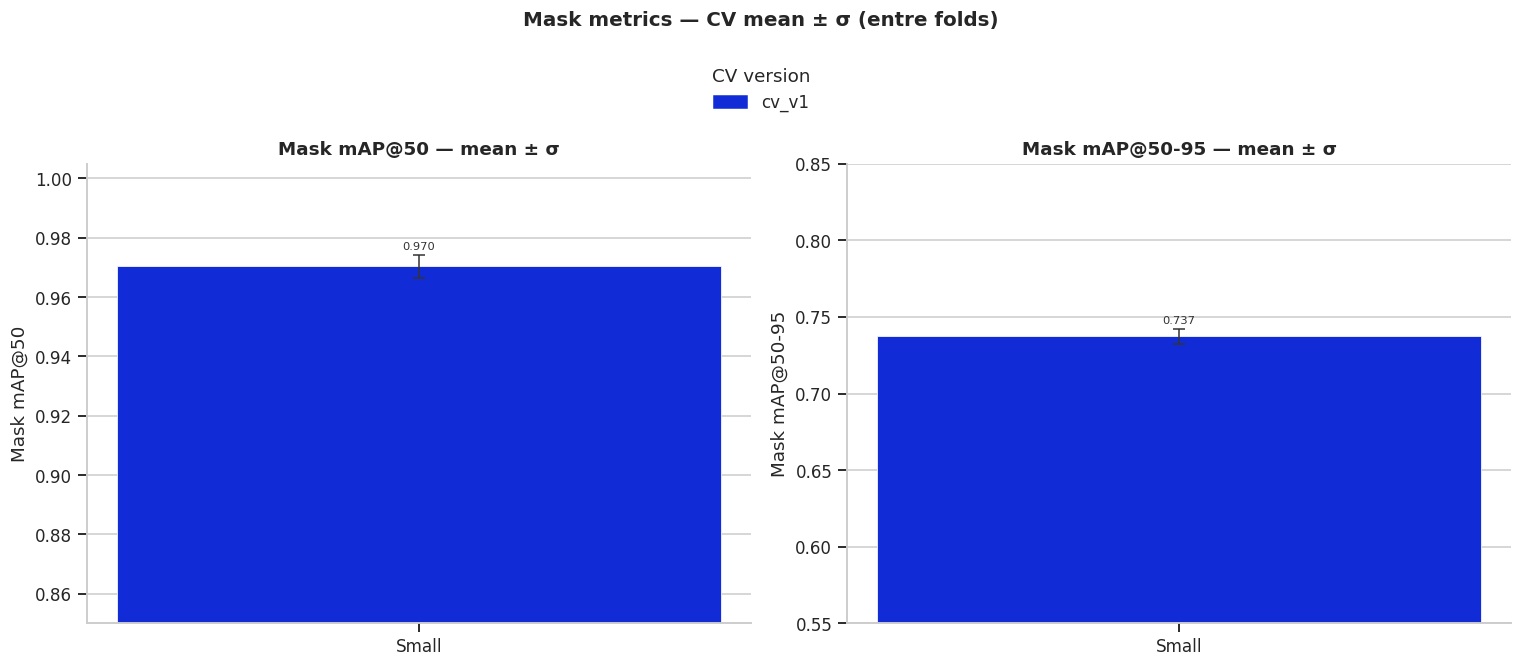

In [27]:
def grouped_bar_with_err(ax, metric_key: str, title: str,
                          ylim=None, fmt="{:.3f}", show_value: bool = True):
    """X = Scale, hue = Version. Bar = mean. Whisker = ±1σ (entre folds)."""
    mean_col = f"{metric_key}_mean"
    std_col  = f"{metric_key}_std"
    pivot_mean = (df_long.pivot_table(index="Model", columns="Version",
                                      values=mean_col, aggfunc="first")
                  .reindex(index=MODELS_PRESENT, columns=VERSIONS_PRESENT))
    pivot_std  = (df_long.pivot_table(index="Model", columns="Version",
                                      values=std_col,  aggfunc="first")
                  .reindex(index=MODELS_PRESENT, columns=VERSIONS_PRESENT))
    n_versions = len(VERSIONS_PRESENT)
    n_models   = len(MODELS_PRESENT)
    x = np.arange(n_models)
    width = 0.8 / max(n_versions, 1)

    for j, v in enumerate(VERSIONS_PRESENT):
        offset = (j - (n_versions - 1) / 2) * width
        means = pivot_mean[v].values
        stds  = pivot_std[v].values
        ax.bar(x + offset, means, width=width,
               color=VERSION_PALETTE.get(v, "#888"),
               edgecolor="white", linewidth=0.5,
               yerr=stds, capsize=4,
               error_kw=dict(ecolor="#333", lw=1.0),
               label=v)
        if show_value:
            for xi, h, s in zip(x + offset, means, stds):
                if np.isfinite(h):
                    s = s if np.isfinite(s) else 0.0
                    ax.annotate(fmt.format(h),
                                (xi, h + s),
                                ha="center", va="bottom", fontsize=7.5, color="#333",
                                xytext=(0, 2), textcoords="offset points")

    ax.set_xticks(x)
    ax.set_xticklabels(MODELS_PRESENT, rotation=0)
    ax.set_title(title)
    ax.set_ylabel(METRIC_LABEL.get(metric_key, metric_key))
    ax.set_xlabel("")
    if ylim:
        ax.set_ylim(*ylim)
    ax.grid(axis="x", visible=False)


# ---- Mask -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
grouped_bar_with_err(axes[0], "map50_m",   "Mask mAP@50 — mean ± σ",   ylim=(0.85, 1.005))
grouped_bar_with_err(axes[1], "map5095_m", "Mask mAP@50-95 — mean ± σ", ylim=(0.55, 0.85))

handles = [Patch(color=VERSION_PALETTE.get(v, "#888"), label=v) for v in VERSIONS_PRESENT]
fig.legend(handles=handles, title="CV version", loc="upper center",
           bbox_to_anchor=(0.5, 1.05), ncol=len(VERSIONS_PRESENT))
fig.suptitle("Mask metrics — CV mean ± σ (entre folds)", y=1.12,
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


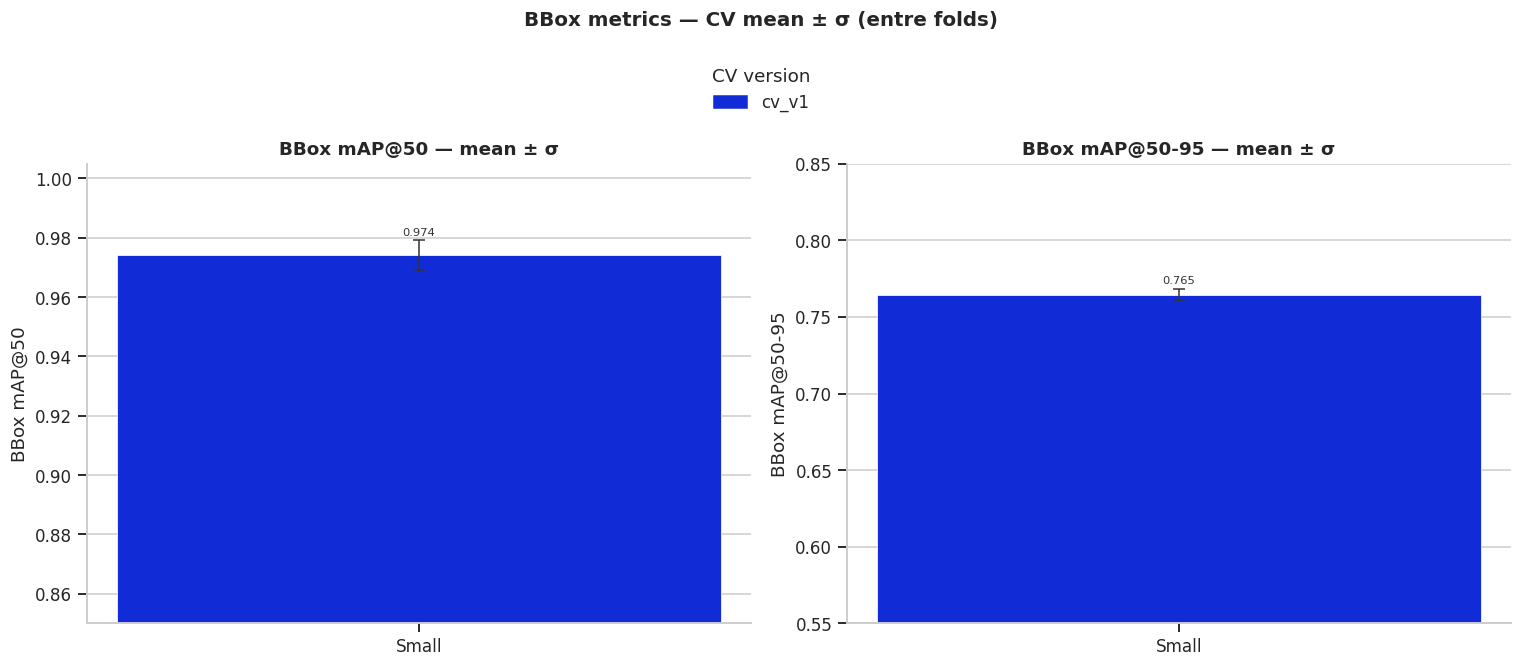

In [28]:
# ---- BBox -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
grouped_bar_with_err(axes[0], "map50_b",   "BBox mAP@50 — mean ± σ",   ylim=(0.85, 1.005))
grouped_bar_with_err(axes[1], "map5095_b", "BBox mAP@50-95 — mean ± σ", ylim=(0.55, 0.85))

handles = [Patch(color=VERSION_PALETTE.get(v, "#888"), label=v) for v in VERSIONS_PRESENT]
fig.legend(handles=handles, title="CV version", loc="upper center",
           bbox_to_anchor=(0.5, 1.05), ncol=len(VERSIONS_PRESENT))
fig.suptitle("BBox metrics — CV mean ± σ (entre folds)", y=1.12,
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


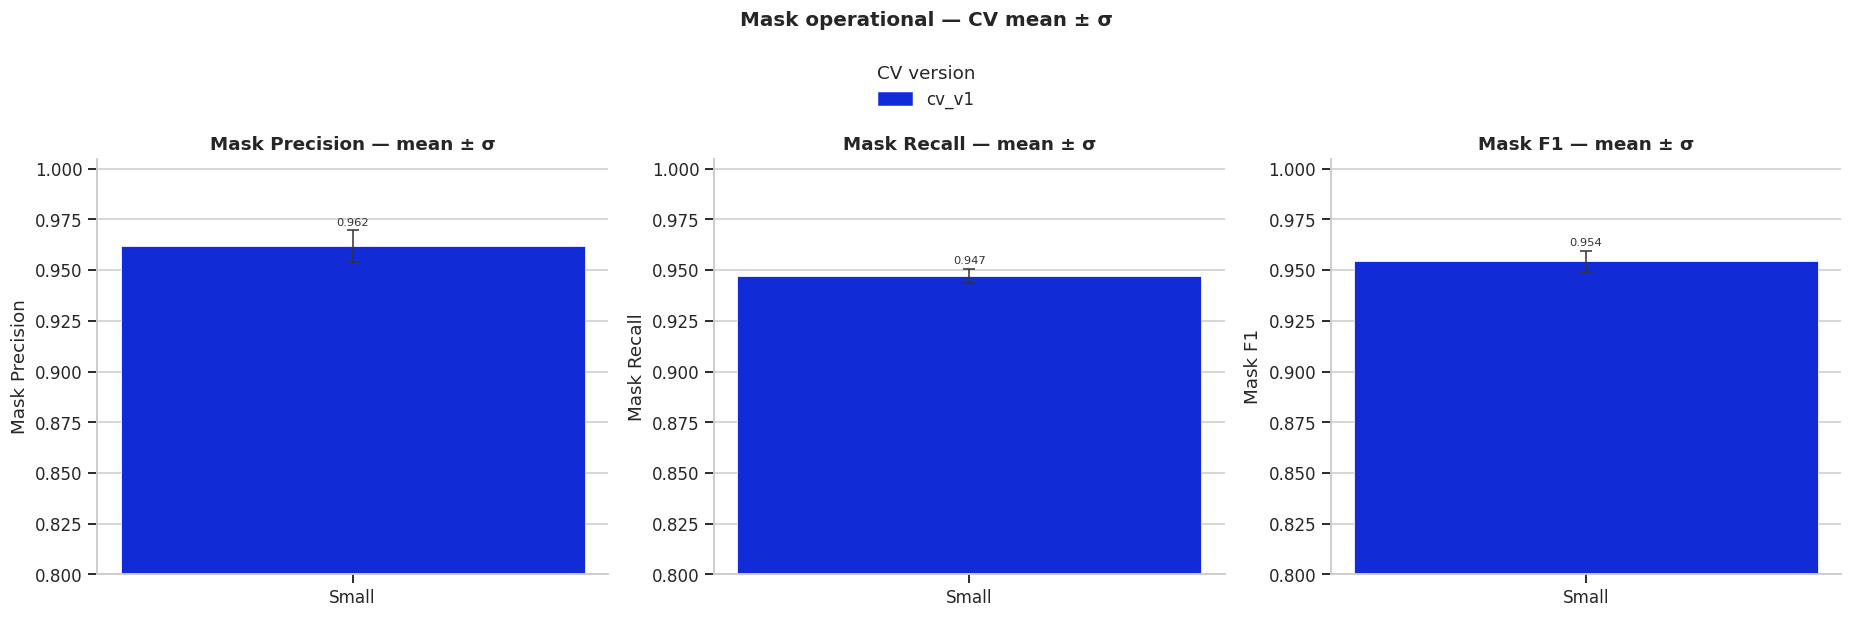

In [29]:
# ---- Operacionais (Precision / Recall / F1) ---------------------------------
fig, axes = plt.subplots(1, 3, figsize=(17, 5.0))
grouped_bar_with_err(axes[0], "precision_m", "Mask Precision — mean ± σ", ylim=(0.80, 1.005))
grouped_bar_with_err(axes[1], "recall_m",    "Mask Recall — mean ± σ",    ylim=(0.80, 1.005))
grouped_bar_with_err(axes[2], "f1_m",        "Mask F1 — mean ± σ",        ylim=(0.80, 1.005))

handles = [Patch(color=VERSION_PALETTE.get(v, "#888"), label=v) for v in VERSIONS_PRESENT]
fig.legend(handles=handles, title="CV version", loc="upper center",
           bbox_to_anchor=(0.5, 1.05), ncol=len(VERSIONS_PRESENT))
fig.suptitle("Mask operational — CV mean ± σ", y=1.12,
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 6. Distribuição por fold — boxplot

Box = quartis dos 5 folds. Pontos sobrepostos = fold individual. Quando aparecer
um outlier (ponto isolado), considere investigar o fold correspondente na §10
(curvas de treino).

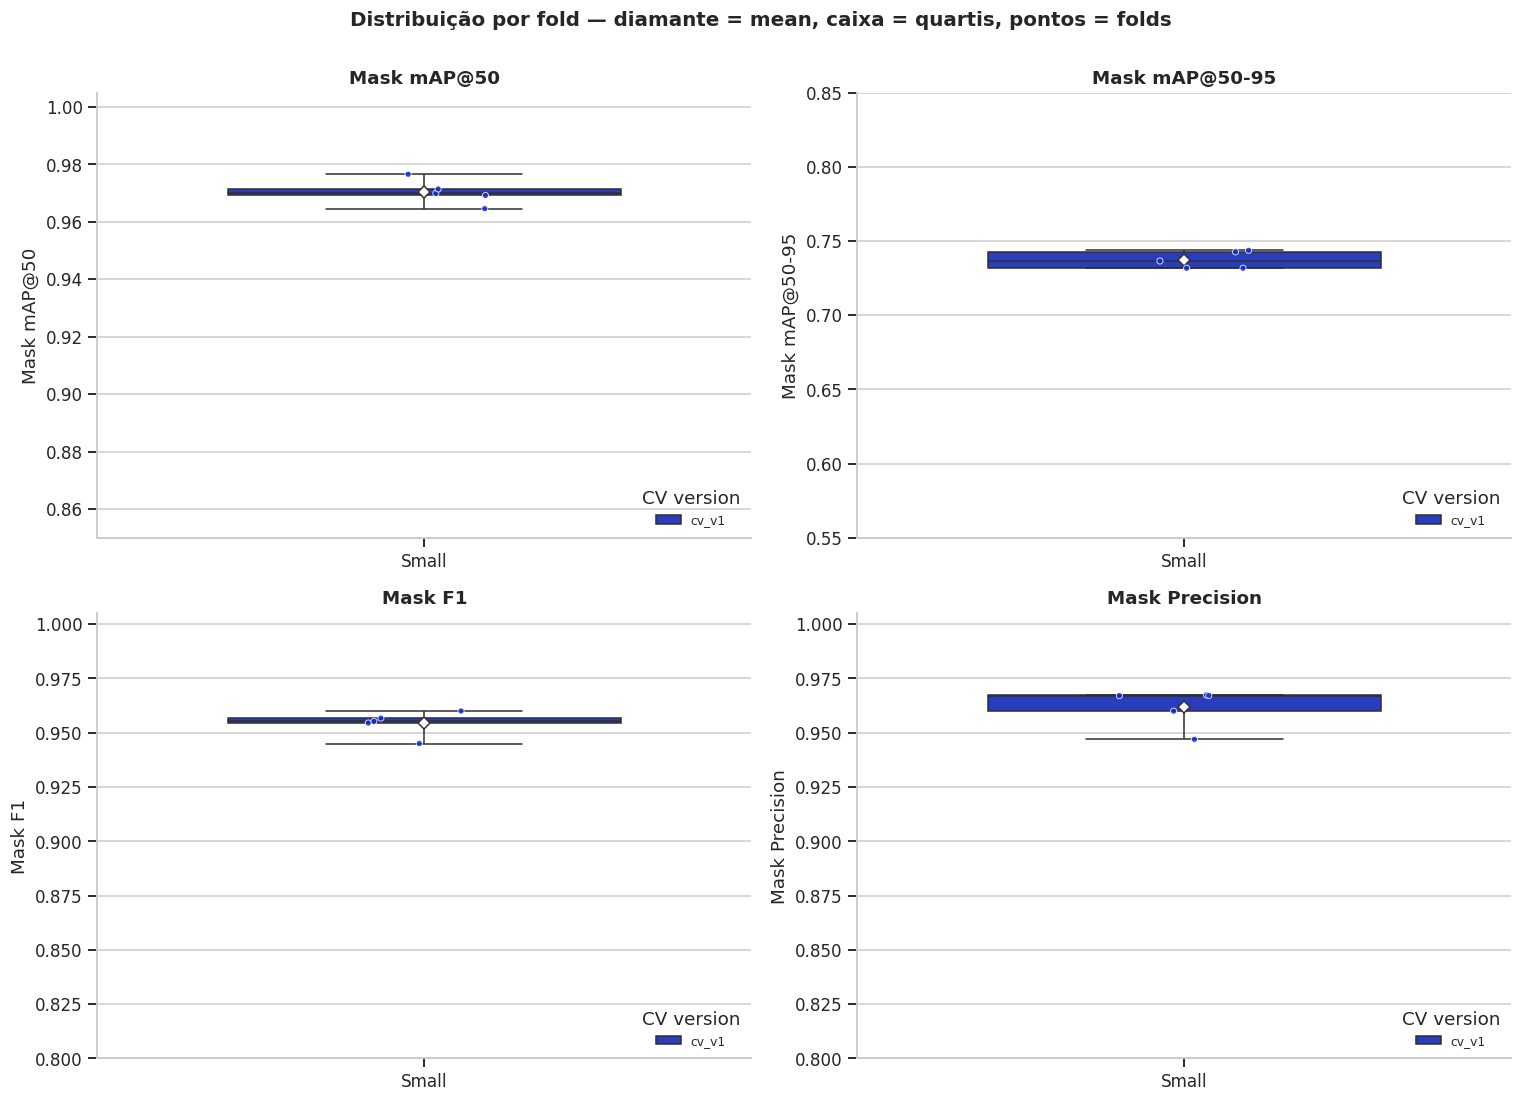

In [30]:
def fold_boxplot(ax, metric_key: str, title: str, ylim=None,
                  show_points: bool = True):
    """Boxplot por scale, hue = version. Pontos = folds individuais."""
    if df_folds.empty or metric_key not in df_folds.columns:
        ax.text(0.5, 0.5, "no data", ha="center", va="center"); ax.axis("off")
        return
    data = df_folds.copy()
    data = data[data["Model"].isin(MODELS_PRESENT)]
    sns.boxplot(
        data=data, x="Model", y=metric_key, hue="Version",
        order=MODELS_PRESENT, hue_order=VERSIONS_PRESENT,
        palette=VERSION_PALETTE, ax=ax,
        whis=(0, 100),  # whiskers = min/max, sem outliers fora
        width=0.6, fliersize=0,
        showmeans=True,
        meanprops=dict(marker="D", markerfacecolor="white",
                       markeredgecolor="#333", markersize=6),
    )
    if show_points:
        sns.stripplot(
            data=data, x="Model", y=metric_key, hue="Version",
            order=MODELS_PRESENT, hue_order=VERSIONS_PRESENT,
            palette=VERSION_PALETTE, ax=ax,
            dodge=True, size=4, alpha=0.85, edgecolor="white", linewidth=0.6,
            legend=False,
        )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(METRIC_LABEL.get(metric_key, metric_key))
    if ylim:
        ax.set_ylim(*ylim)
    # remove a legend duplicada do boxplot quando temos stripplot embaixo
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles[:len(VERSIONS_PRESENT)], labels[:len(VERSIONS_PRESENT)],
                  title="CV version", loc="lower right", fontsize=8)


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fold_boxplot(axes[0, 0], "map50_m",   "Mask mAP@50",   ylim=(0.85, 1.005))
fold_boxplot(axes[0, 1], "map5095_m", "Mask mAP@50-95", ylim=(0.55, 0.85))
fold_boxplot(axes[1, 0], "f1_m",      "Mask F1",       ylim=(0.80, 1.005))
fold_boxplot(axes[1, 1], "precision_m", "Mask Precision", ylim=(0.80, 1.005))
fig.suptitle("Distribuição por fold — diamante = mean, caixa = quartis, pontos = folds",
             y=1.00, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 7. Pontos por fold — strip chart

Cada ponto = um fold. Útil para ver **explicitamente** os 5 valores e identificar
qual fold puxa a média para cima/baixo. Linha horizontal = mean.

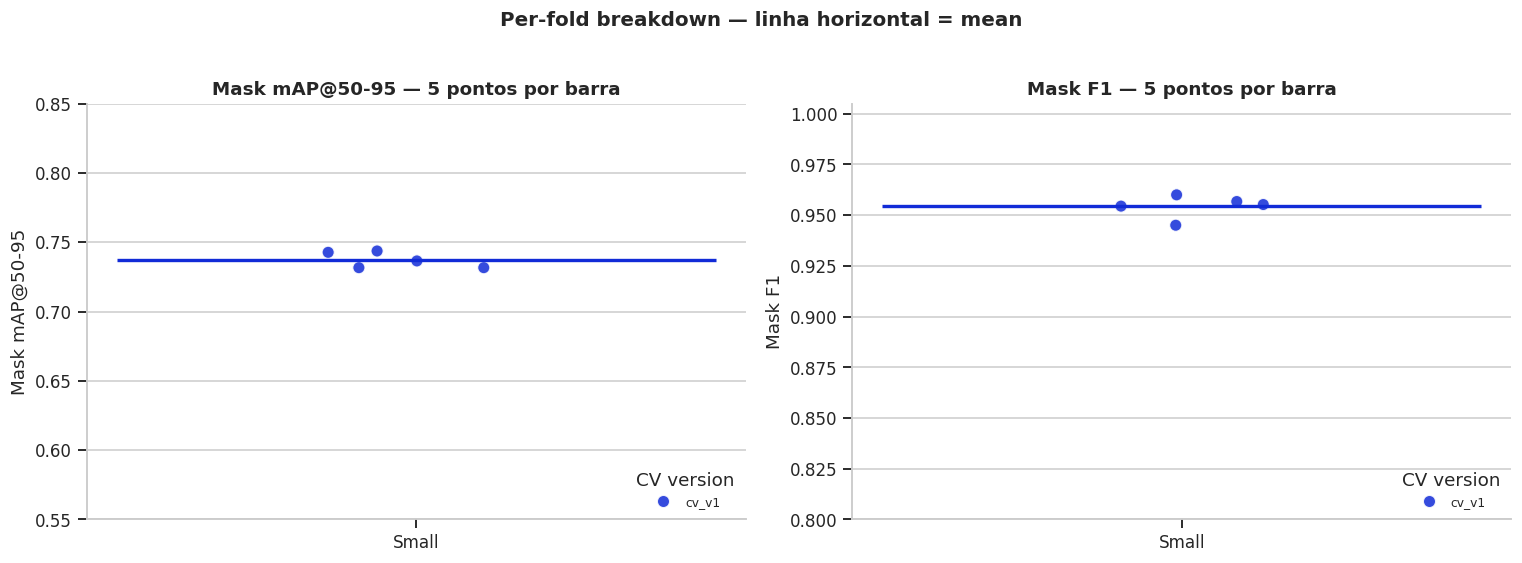

In [31]:
def strip_with_mean(ax, metric_key: str, title: str, ylim=None):
    if df_folds.empty or metric_key not in df_folds.columns:
        ax.text(0.5, 0.5, "no data", ha="center", va="center"); ax.axis("off")
        return
    data = df_folds[df_folds["Model"].isin(MODELS_PRESENT)]
    sns.stripplot(
        data=data, x="Model", y=metric_key, hue="Version",
        order=MODELS_PRESENT, hue_order=VERSIONS_PRESENT,
        palette=VERSION_PALETTE, ax=ax,
        dodge=True, size=8, alpha=0.85, edgecolor="white", linewidth=0.8,
    )
    # mean line per (version, model)
    means = (data.groupby(["Version", "Model"])[metric_key].mean()
             .reindex(pd.MultiIndex.from_product([VERSIONS_PRESENT, MODELS_PRESENT],
                                                 names=["Version", "Model"])))
    n_v = len(VERSIONS_PRESENT)
    width = 0.8 / max(n_v, 1)
    for j, v in enumerate(VERSIONS_PRESENT):
        for i, m in enumerate(MODELS_PRESENT):
            mean = means.get((v, m))
            if mean is None or not np.isfinite(mean):
                continue
            x_center = i + (j - (n_v - 1) / 2) * width
            ax.hlines(mean, x_center - width * 0.35, x_center + width * 0.35,
                      color=VERSION_PALETTE.get(v, "#444"), linewidth=2.2, zorder=4)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(METRIC_LABEL.get(metric_key, metric_key))
    if ylim:
        ax.set_ylim(*ylim)
    ax.legend(title="CV version", loc="lower right", fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(14, 5.0))
strip_with_mean(axes[0], "map5095_m", "Mask mAP@50-95 — 5 pontos por barra",
                ylim=(0.55, 0.85))
strip_with_mean(axes[1], "f1_m",      "Mask F1 — 5 pontos por barra",
                ylim=(0.80, 1.005))
fig.suptitle("Per-fold breakdown — linha horizontal = mean",
             y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 8. Coeficiente de variação (CV = σ / μ)

**Coeficiente de variação** (CV) mede dispersão **normalizada**. Independe da escala
da métrica e permite comparar a estabilidade de mAP vs Recall vs F1 lado a lado.

| CV (interpretação heurística) | Significado |
|-------------------------------|-------------|
| < 1 %   | Métrica **muito estável** — split não importa. |
| 1 – 3 % | Métrica estável — discrepâncias pequenas entre folds. |
| 3 – 8 % | Variação moderada — investigar fold(s) divergente(s). |
| > 8 %   | Variação alta — split tem grande influência (ou o modelo é instável). |


### Coeficiente de variação — % (menor é melhor)

Version,cv_v1
Model,Small
Metric,
Mask mAP@50-95,0.70
Mask mAP@50,0.40
Mask F1,0.52
Mask Precision,0.82
Mask Recall,0.38
BBox mAP@50-95,0.48
BBox mAP@50,0.52
BBox F1,0.64


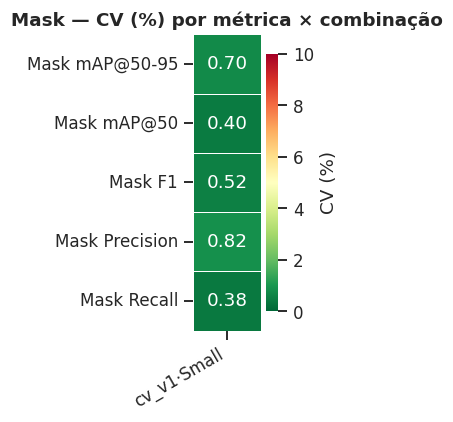

In [32]:
cv_data = []
for _, r in df_long.iterrows():
    for k in METRIC_KEYS_ALL:
        cv_data.append({
            "Version": r["Version"],
            "Model":   r["Model"],
            "Metric":  METRIC_LABEL.get(k, k),
            "CV (%)":  r.get(f"{k}_cv", np.nan) * 100,
        })
cv_df = pd.DataFrame(cv_data)

cv_pivot = (cv_df.pivot_table(index="Metric",
                              columns=["Version", "Model"],
                              values="CV (%)", aggfunc="first")
            .reindex(columns=pd.MultiIndex.from_product(
                [VERSIONS_PRESENT, MODELS_PRESENT], names=["Version", "Model"]
            )))

# Ordena linhas: Mask primeiro, depois BBox
mask_labels = [METRIC_LABEL[k] for k in METRIC_KEYS_MASK]
box_labels  = [METRIC_LABEL[k] for k in METRIC_KEYS_BOX]
cv_pivot = cv_pivot.reindex(mask_labels + box_labels)

display(Markdown("### Coeficiente de variação — % (menor é melhor)"))
display(cv_pivot.style
        .format("{:.2f}", na_rep="—")
        .background_gradient(cmap="RdYlGn_r", vmin=0, vmax=10)
        .set_caption("Verde = CV baixo (métrica estável) · Vermelho = CV alto (instável)"))


# Heatmap só pra Mask (resumo visual)
fig, ax = plt.subplots(figsize=(1.6 + 1.4 * len(MODELS_PRESENT) * len(VERSIONS_PRESENT), 4.0))
mask_only = cv_pivot.loc[mask_labels]
if not mask_only.empty:
    sns.heatmap(mask_only.values.astype(float), ax=ax, cmap="RdYlGn_r",
                vmin=0, vmax=10, annot=True, fmt=".2f", cbar_kws=dict(label="CV (%)"),
                linewidths=0.4, linecolor="white",
                xticklabels=[f"{v}·{m}" for v, m in mask_only.columns],
                yticklabels=mask_only.index)
    ax.set_title("Mask — CV (%) por métrica × combinação", fontweight="bold")
    plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 9. Best epoch — em qual época o `best.pt` foi salvo?

Se um fold converge em ~30 épocas e outro em ~120, isso sugere variabilidade no
processo de treino (LR/scheduler/seed-de-dataloader). A distribuição de `best_epoch` é
informativa — se for muito apertada, todos os folds convergem juntos; se for ampla,
o critério de early-stopping pode estar sendo acionado em folds "fáceis".

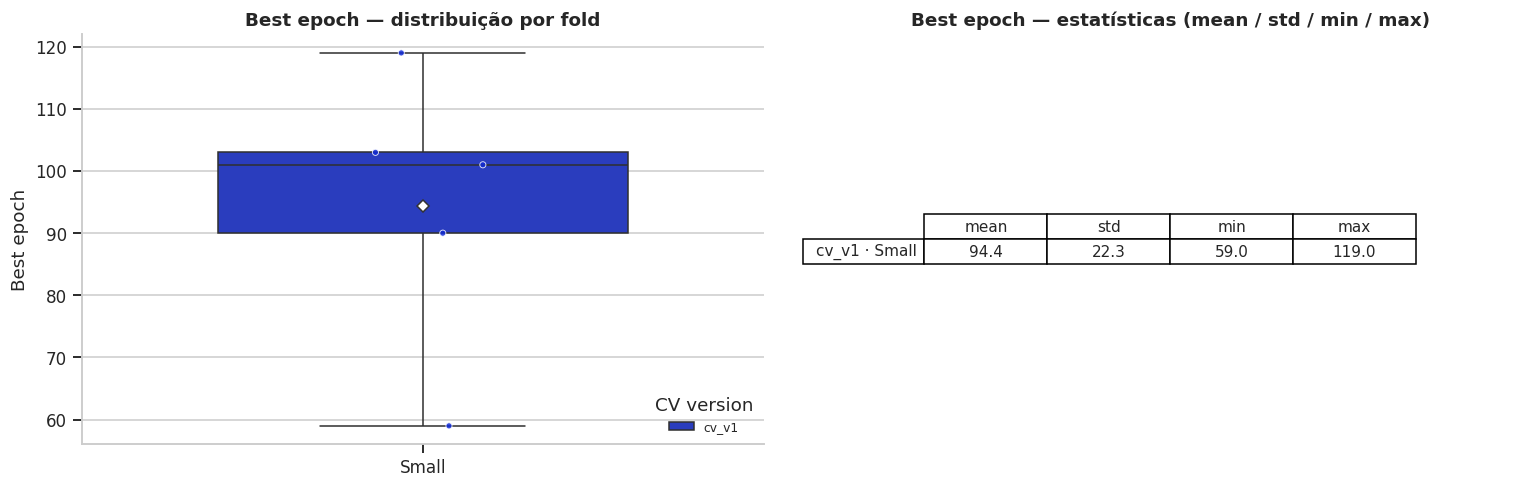

In [33]:
if df_folds.empty or "best_epoch" not in df_folds.columns:
    print("[skip] sem coluna best_epoch")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

    # (a) boxplot best_epoch
    fold_boxplot(axes[0], "best_epoch", "Best epoch — distribuição por fold",
                 ylim=None)

    # (b) tabela com agg
    tab = (df_folds.groupby(["Version", "Model"])["best_epoch"]
           .agg(["mean", "std", "min", "max"]).round(1))
    tab.columns = ["mean", "std", "min", "max"]
    tab = tab.reindex(pd.MultiIndex.from_product([VERSIONS_PRESENT, MODELS_PRESENT],
                                                 names=["Version", "Model"]))
    ax = axes[1]
    ax.axis("off")
    table = ax.table(cellText=tab.fillna("—").astype(str).values,
                     rowLabels=[f"{v} · {m}" for v, m in tab.index],
                     colLabels=tab.columns,
                     cellLoc="center", loc="center", colWidths=[0.18]*4)
    table.auto_set_font_size(False); table.set_fontsize(10)
    table.scale(1, 1.3)
    ax.set_title("Best epoch — estatísticas (mean / std / min / max)")

    plt.tight_layout()
    plt.show()


## 10. Curvas de treino — Mask mAP@50-95 por fold (por scale)

Cada subplot = um scale. Cada linha = um fold. Linha clara = curva bruta;
linha grossa = suavizada (janela 5). Marcador = best epoch do fold. Útil para detectar
fold "ruim" (curva clara abaixo das outras) ou convergência inconsistente.

Requer `runs/fold_<k>/results.csv` — se não estiver disponível, a seção é pulada.

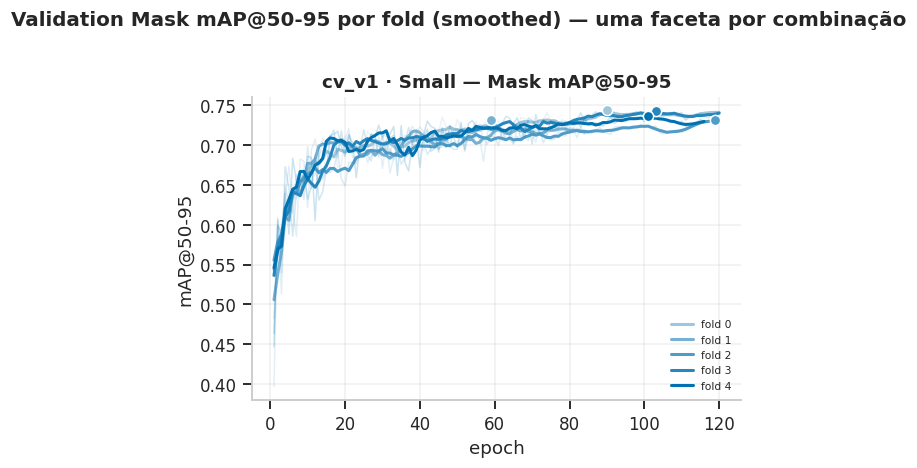

In [34]:
def _has_curve_data(row) -> bool:
    return bool(row.get("_fold_dfs")) and any(
        "metrics/mAP50-95(M)" in df for df in row["_fold_dfs"].values()
    )


has_curves = df_long[df_long.apply(_has_curve_data, axis=1)]
if has_curves.empty:
    print("[skip] nenhuma combinação tem runs/fold_<k>/results.csv com a coluna "
          "metrics/mAP50-95(M).")
else:
    WINDOW = 5
    n = len(has_curves)
    ncols = min(3, max(1, n))
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.2 * nrows),
                             squeeze=False, sharex=False)
    axes_flat = axes.flatten()

    for ax_i, (_, r) in enumerate(has_curves.iterrows()):
        ax = axes_flat[ax_i]
        m = r["Model"]; v = r["Version"]
        base_color = MODEL_PALETTE[m]
        fold_colors = sns.light_palette(base_color, n_colors=len(r["_fold_dfs"]) + 2,
                                        reverse=False)[2:]
        for (k, df), c in zip(sorted(r["_fold_dfs"].items()), fold_colors):
            if "metrics/mAP50-95(M)" not in df:
                continue
            eps = df["epoch"].to_numpy()
            y = df["metrics/mAP50-95(M)"].to_numpy()
            ax.plot(eps, y, color=c, alpha=0.20, lw=1)
            ax.plot(eps, smooth(y, WINDOW), color=c, lw=2.0, label=f"fold {k}")
            b = int(np.argmax(y))
            ax.scatter([eps[b]], [y[b]], color=c, s=45, zorder=5,
                       edgecolor="white", lw=1.0)
        ax.set_title(f"{v} · {m} — Mask mAP@50-95")
        ax.set_xlabel("epoch"); ax.set_ylabel("mAP@50-95")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="lower right", fontsize=7, ncol=1)

    for j in range(n, len(axes_flat)):
        axes_flat[j].axis("off")
    fig.suptitle("Validation Mask mAP@50-95 por fold (smoothed) — uma faceta por combinação",
                 y=1.01, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


## 11. Train vs Val seg_loss — overfitting check por fold

Grade `combinação × fold`. Train (sólido) vs Val (tracejado). Útil para confirmar
que o gap de overfitting é consistente entre folds (e não um artefato de um split).

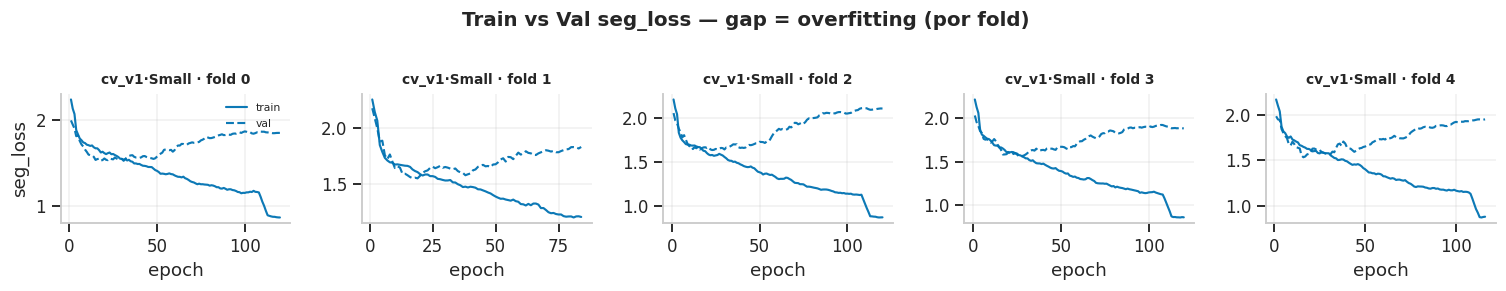

In [35]:
has_loss = []
for _, r in df_long.iterrows():
    if not r["_fold_dfs"]:
        continue
    if any(("train/seg_loss" in df) and ("val/seg_loss" in df)
           for df in r["_fold_dfs"].values()):
        has_loss.append(r)

if not has_loss:
    print("[skip] nenhuma combinação tem train/val seg_loss nos results.csv.")
else:
    WINDOW = 5
    n_combos = len(has_loss)
    # uma linha por combinação, uma coluna por fold (até k=5 esperado)
    max_folds = max(len(r["_fold_dfs"]) for r in has_loss)
    fig, axes = plt.subplots(n_combos, max_folds,
                             figsize=(2.8 * max_folds, 2.6 * n_combos),
                             squeeze=False, sharex=False)
    for i, r in enumerate(has_loss):
        m, v = r["Model"], r["Version"]
        c = MODEL_PALETTE[m]
        for j in range(max_folds):
            ax = axes[i, j]
            df = r["_fold_dfs"].get(j)
            if df is None or "train/seg_loss" not in df or "val/seg_loss" not in df:
                ax.axis("off"); continue
            eps = df["epoch"].to_numpy()
            ax.plot(eps, smooth(df["train/seg_loss"].to_numpy(), WINDOW),
                    color=c, lw=1.4, alpha=0.95, label="train")
            ax.plot(eps, smooth(df["val/seg_loss"].to_numpy(), WINDOW),
                    color=c, lw=1.4, alpha=0.95, ls="--", label="val")
            ax.set_title(f"{v}·{m} · fold {j}", fontsize=9)
            ax.grid(True, alpha=0.3)
            if i == n_combos - 1:
                ax.set_xlabel("epoch")
            if j == 0:
                ax.set_ylabel("seg_loss")
            if i == 0 and j == 0:
                ax.legend(loc="upper right", fontsize=7)
    fig.suptitle("Train vs Val seg_loss — gap = overfitting (por fold)",
                 y=1.01, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


## 12. Estabilidade do treino — σ das últimas 10 épocas (avg entre folds)

σ baixo nas últimas 10 épocas = modelo "assenta" e oscila pouco perto do best.
Métrica complementar ao CV da §8 (que mede dispersão **entre folds**); esta mede
dispersão **dentro** do treino, agregada entre folds.

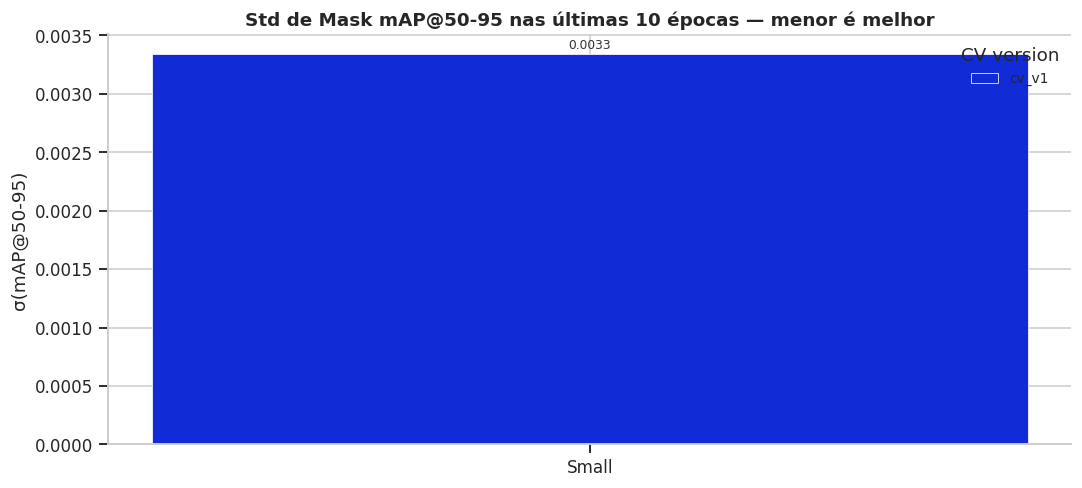

In [36]:
mask = df_long["Stability (avg std last10)"].notna()
if not mask.any():
    print("[skip] sem dados de stability (precisa de runs/fold_<k>/results.csv).")
else:
    fig, ax = plt.subplots(figsize=(10, 4.6))
    sub = df_long[mask].copy()
    pivot = (sub.pivot_table(index="Model", columns="Version",
                             values="Stability (avg std last10)", aggfunc="first")
             .reindex(index=MODELS_PRESENT, columns=VERSIONS_PRESENT))
    n_v = len(VERSIONS_PRESENT); n_m = len(MODELS_PRESENT)
    x = np.arange(n_m); width = 0.8 / max(n_v, 1)
    for j, v in enumerate(VERSIONS_PRESENT):
        offset = (j - (n_v - 1) / 2) * width
        vals = pivot[v].values
        ax.bar(x + offset, vals, width=width,
               color=VERSION_PALETTE.get(v, "#888"),
               edgecolor="white", linewidth=0.5, label=v)
        for xi, h in zip(x + offset, vals):
            if np.isfinite(h):
                ax.annotate(f"{h:.4f}", (xi, h), ha="center", va="bottom",
                            fontsize=8, color="#333",
                            xytext=(0, 1.5), textcoords="offset points")
    ax.set_xticks(x); ax.set_xticklabels(MODELS_PRESENT)
    ax.set_title("Std de Mask mAP@50-95 nas últimas 10 épocas — menor é melhor")
    ax.set_ylabel("σ(mAP@50-95)"); ax.set_xlabel("")
    ax.legend(title="CV version", loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.show()


## 13. Scaling: `Mask mAP@50-95` × tamanho do modelo (com error bar)

Curva de scaling **com a incerteza CV** desenhada. Marca-se mean ± std (σ entre folds)
em cada scale. Eixo X em log nos params.

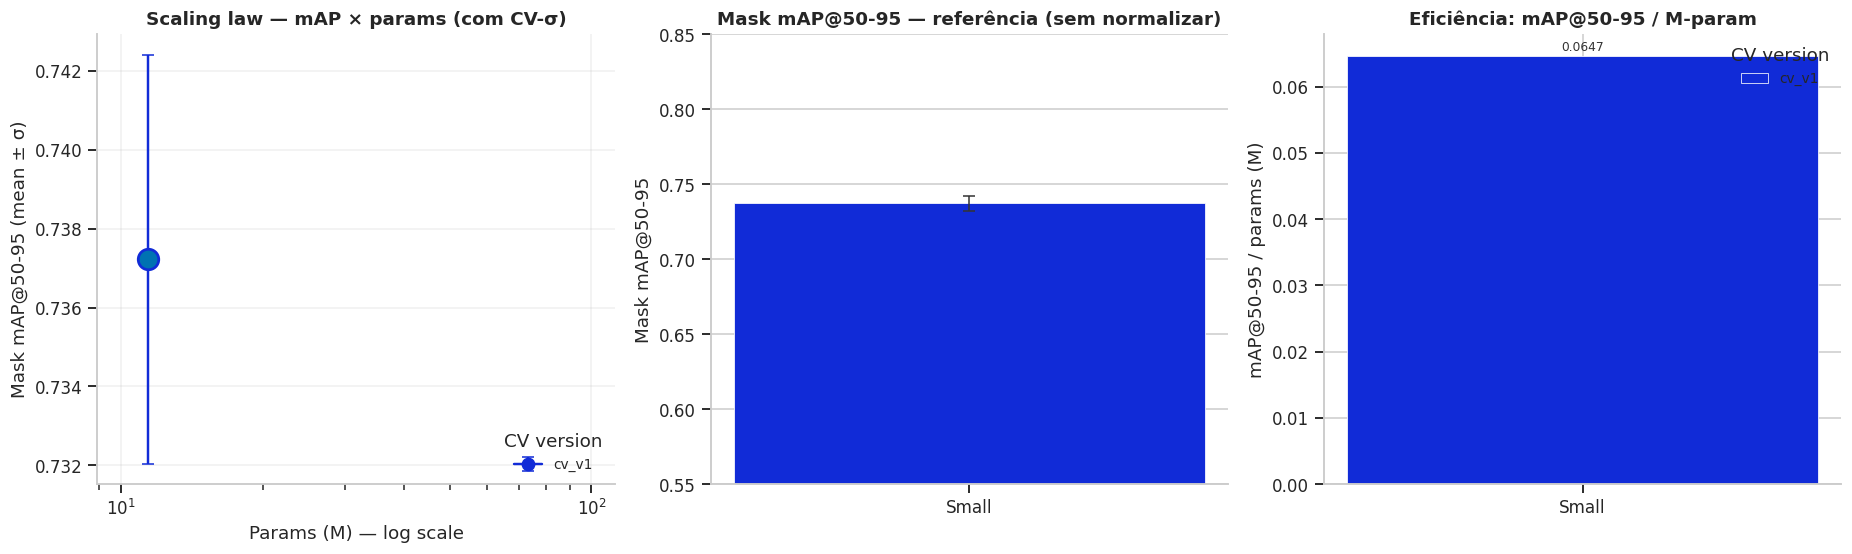

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

# (a) mAP × params (log) com errorbars
ax = axes[0]
for v in VERSIONS_PRESENT:
    sub = (df_long[df_long["Version"] == v]
           .dropna(subset=["Params (M)", "map5095_m_mean"])
           .sort_values("Params (M)"))
    if sub.empty:
        continue
    color = VERSION_PALETTE.get(v, "#888")
    ax.errorbar(sub["Params (M)"], sub["map5095_m_mean"],
                yerr=sub["map5095_m_std"], color=color, marker="o",
                markersize=8, lw=1.6, capsize=4, label=v, zorder=2)
    for _, r in sub.iterrows():
        ax.scatter(r["Params (M)"], r["map5095_m_mean"],
                   s=180, color=MODEL_PALETTE[r["Model"]],
                   edgecolor=color, lw=1.8, zorder=3)
ax.set_xscale("log")
ax.set_xlabel("Params (M) — log scale")
ax.set_ylabel("Mask mAP@50-95 (mean ± σ)")
ax.set_title("Scaling law — mAP × params (com CV-σ)")
ax.legend(title="CV version", loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)

# (b) eficiência por tempo: mAP / min de treino (médio por fold)
df_long["mAP / min (per fold)"] = (df_long["map5095_m_mean"]
                                   / df_long["Train time / fold (min)"])
ax = axes[1]
grouped_bar_with_err(ax, "map5095_m",
                     "Mask mAP@50-95 — referência (sem normalizar)",
                     ylim=(0.55, 0.85), show_value=False)

# (c) eficiência por parâmetro
df_long["mAP / M-param"] = df_long["map5095_m_mean"] / df_long["Params (M)"]
ax = axes[2]
pivot = (df_long.pivot_table(index="Model", columns="Version",
                             values="mAP / M-param", aggfunc="first")
         .reindex(index=MODELS_PRESENT, columns=VERSIONS_PRESENT))
n_v = len(VERSIONS_PRESENT); n_m = len(MODELS_PRESENT)
x = np.arange(n_m); width = 0.8 / max(n_v, 1)
for j, v in enumerate(VERSIONS_PRESENT):
    offset = (j - (n_v - 1) / 2) * width
    vals = pivot[v].values
    ax.bar(x + offset, vals, width=width,
           color=VERSION_PALETTE.get(v, "#888"),
           edgecolor="white", linewidth=0.5, label=v)
    for xi, h in zip(x + offset, vals):
        if np.isfinite(h):
            ax.annotate(f"{h:.4f}", (xi, h), ha="center", va="bottom",
                        fontsize=8, color="#333",
                        xytext=(0, 1.5), textcoords="offset points")
ax.set_xticks(x); ax.set_xticklabels(MODELS_PRESENT)
ax.set_title("Eficiência: mAP@50-95 / M-param")
ax.set_ylabel("mAP@50-95 / params (M)")
ax.legend(title="CV version", loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()


## 14. Pareto: `mAP@50-95` × `Train time total` (com error bars)

**Train time total** = soma do tempo de treino dos k folds (custo real de
fazer CV completo no scale). Pareto frontier global = combinação que não é dominada
nas duas dimensões.

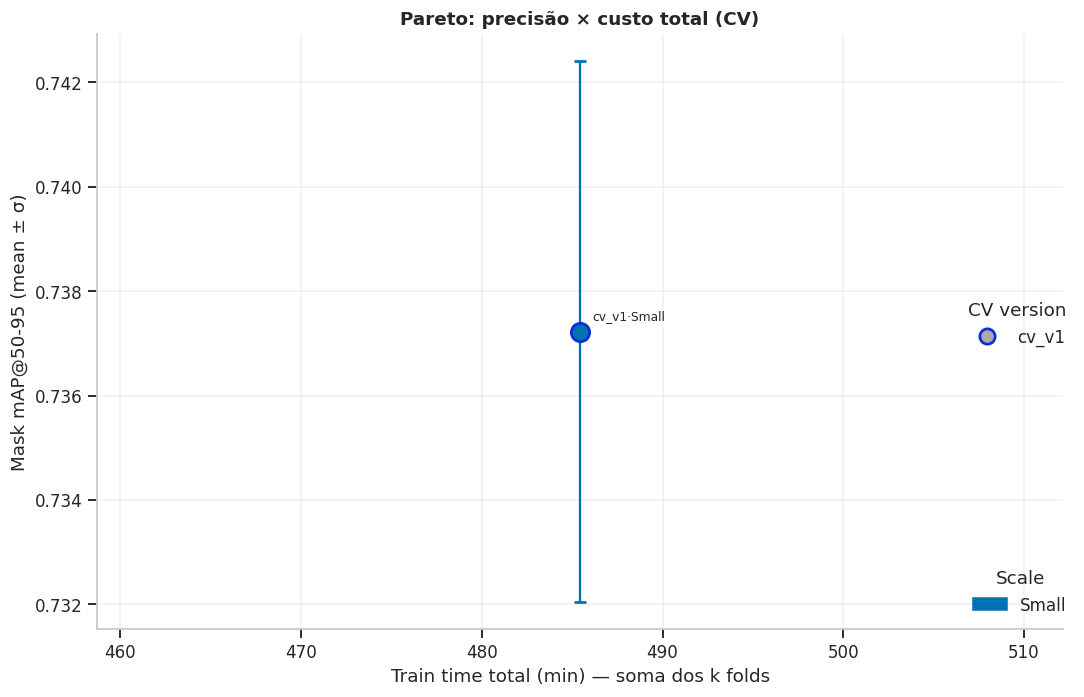

In [38]:
fig, ax = plt.subplots(figsize=(10, 6.5))
SHAPE_BY_VERSION = ["o", "s", "D", "^", "v", "P", "X", "*"]
shape_map = {v: SHAPE_BY_VERSION[i % len(SHAPE_BY_VERSION)]
             for i, v in enumerate(VERSIONS_PRESENT)}

for _, r in df_long.iterrows():
    if not np.isfinite(r.get("Train time total (min)", np.nan)):
        continue
    ax.errorbar(r["Train time total (min)"], r["map5095_m_mean"],
                yerr=r["map5095_m_std"],
                color=MODEL_PALETTE[r["Model"]],
                marker=shape_map[r["Version"]],
                markersize=12, capsize=4,
                markeredgecolor=VERSION_PALETTE.get(r["Version"], "#444"),
                markeredgewidth=1.8, zorder=3)
    ax.annotate(f"{r['Version']}·{r['Model']}",
                (r["Train time total (min)"], r["map5095_m_mean"]),
                xytext=(8, 8), textcoords="offset points", fontsize=8)

# Pareto frontier
pf = (df_long.dropna(subset=["Train time total (min)", "map5095_m_mean"])
      .sort_values("Train time total (min)"))
front = []; best_y = -np.inf
for _, r in pf.iterrows():
    if r["map5095_m_mean"] > best_y:
        front.append((r["Train time total (min)"], r["map5095_m_mean"]))
        best_y = r["map5095_m_mean"]
if len(front) >= 2:
    fx, fy = zip(*front)
    ax.plot(fx, fy, color=NEUTRAL, ls="--", lw=1.4, alpha=0.7, label="Pareto frontier")

size_handles = [Patch(color=MODEL_PALETTE[m], label=m) for m in MODELS_PRESENT]
ver_handles  = [
    plt.Line2D([0], [0], marker=shape_map[v], color="w",
               markerfacecolor="#aaa",
               markeredgecolor=VERSION_PALETTE.get(v, "#444"),
               markeredgewidth=1.8, markersize=10, label=v)
    for v in VERSIONS_PRESENT
]
leg1 = ax.legend(handles=size_handles, title="Scale", loc="lower right",
                 bbox_to_anchor=(1.02, 0.0))
ax.add_artist(leg1)
ax.legend(handles=ver_handles, title="CV version", loc="lower right",
          bbox_to_anchor=(1.02, 0.45))

ax.set_xlabel("Train time total (min) — soma dos k folds")
ax.set_ylabel("Mask mAP@50-95 (mean ± σ)")
ax.set_title("Pareto: precisão × custo total (CV)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 15. Hiperparâmetros aplicados (lidos de `runs/fold_0/args.yaml`)

Esses são os hp que o `train_all_models_cv.py` efetivamente passou ao Ultralytics
para cada scale. Útil para auditar se cada scale carregou o `best_hyperparameters.yaml`
correto do `hpo_v3`. (O fold 0 é representativo: os outros folds usam exatamente os
mesmos hp; só o dataset muda.)

In [39]:
hp_cols = ["optimizer", "lr0", "lrf", "amp", "batch", "epochs",
           "patience", "imgsz", "close_mosaic", "erasing",
           "weight_decay", "momentum", "dropout", "cos_lr"]

hp_rows = []
for _, r in df_long.iterrows():
    a = r["_args"] or {}
    if not a:
        continue
    hp_rows.append({
        "Version": r["Version"], "Model": r["Model"],
        **{k: a.get(k) for k in hp_cols}
    })

if not hp_rows:
    print("[skip] nenhum args.yaml encontrado (runs/fold_0/args.yaml).")
else:
    hp = pd.DataFrame(hp_rows).set_index(["Version", "Model"])[hp_cols].T
    hp = hp.reindex(columns=pd.MultiIndex.from_product(
        [VERSIONS_PRESENT, MODELS_PRESENT], names=["Version", "Model"]
    ))

    def style_diff_row(row: pd.Series):
        if row.dropna().empty:
            return ["" for _ in row]
        ref = row.dropna().iloc[0]
        return [
            "background-color: #FFF3CD" if (pd.notna(v) and str(v) != str(ref)) else ""
            for v in row
        ]

    display(Markdown("### Hiperparâmetros chave (cor amarela = difere do primeiro scale)"))
    display(hp.style.apply(style_diff_row, axis=1)
            .set_caption("Linha = hp · Coluna = (version, scale)"))


### Hiperparâmetros chave (cor amarela = difere do primeiro scale)

Version,cv_v1
Model,Small
optimizer,MuSGD
lr0,0.002370
lrf,0.015880
amp,False
batch,16
epochs,120
patience,25
imgsz,640
close_mosaic,10


## 16. Insights automáticos

In [40]:
insights = []

# 1. Champion global por Mask mAP@50-95
ch = df_long.loc[df_long["map5095_m_mean"].idxmax()]
insights.append(
    f"**Champion global**: `{ch['Version']} · {ch['Model']}` com "
    f"Mask mAP@50-95 = **{ch['map5095_m_mean']:.4f} ± {ch['map5095_m_ci95']:.4f}** "
    f"(CI95, k={int(ch['k_folds'])}, CV = {ch['map5095_m_cv']*100:.2f}%)."
)

# 2. Mais estável (menor CV em Mask mAP@50-95)
stable = df_long.dropna(subset=["map5095_m_cv"])
if not stable.empty:
    s = stable.loc[stable["map5095_m_cv"].idxmin()]
    insights.append(
        f"**Métrica mais estável**: `{s['Version']} · {s['Model']}` "
        f"com CV(Mask mAP@50-95) = {s['map5095_m_cv']*100:.2f}% "
        f"(σ = {s['map5095_m_std']:.4f})."
    )

# 3. Menos estável
if not stable.empty:
    s = stable.loc[stable["map5095_m_cv"].idxmax()]
    insights.append(
        f"**Métrica menos estável**: `{s['Version']} · {s['Model']}` "
        f"com CV(Mask mAP@50-95) = {s['map5095_m_cv']*100:.2f}% — "
        f"vale investigar a §10 (curvas por fold) deste scale."
    )

# 4. Champion por scale
display(Markdown("**Champion por scale (CV):**"))
champ_per_m = (
    df_long.sort_values("map5095_m_mean", ascending=False)
    .groupby("Model", as_index=False).first()
    .set_index("Model").reindex(MODELS_PRESENT)
)
view = pd.DataFrame({
    "Version":         champ_per_m["Version"],
    "Mask mAP@50-95":  champ_per_m.apply(
        lambda r: mean_ci_str(r["map5095_m_mean"], r["map5095_m_ci95"]), axis=1),
    "CV (%)":          (champ_per_m["map5095_m_cv"] * 100).round(2),
    "Best epoch (avg)": champ_per_m["best_epoch_mean"].round(1),
}).fillna("—")
display(view.style.set_caption("Champion por scale — mean ± CI95"))

# 5. Quality / cost (mAP/sqrt(time * params)) — se houver train time
if df_long["Train time total (min)"].notna().any():
    df_long["Quality/Cost"] = (
        df_long["map5095_m_mean"]
        / np.sqrt(df_long["Train time total (min)"] * df_long["Params (M)"])
    )
    qc = df_long.dropna(subset=["Quality/Cost"])
    if not qc.empty:
        q = qc.loc[qc["Quality/Cost"].idxmax()]
        insights.append(
            f"**Melhor quality/cost (CV completa)**: `{q['Version']} · {q['Model']}` "
            f"(score = {q['Quality/Cost']:.4f})."
        )

# 6. Diminishing returns dentro de cada versão
for v in VERSIONS_PRESENT:
    sub = (df_long[df_long["Version"] == v]
           .dropna(subset=["Params (M)", "map5095_m_mean"])
           .sort_values("Params (M)").reset_index(drop=True))
    if len(sub) < 2:
        continue
    deltas = sub["map5095_m_mean"].diff()
    bad = deltas[deltas < 0]
    if len(bad):
        idx = bad.index[0]
        prev = sub.iloc[idx - 1]
        cur  = sub.iloc[idx]
        insights.append(
            f"**⚠ Diminishing returns em `{v}`**: `{cur['Model']}` "
            f"({cur['Params (M)']:.1f}M, mean={cur['map5095_m_mean']:.4f}) "
            f"piorou vs `{prev['Model']}` (mean={prev['map5095_m_mean']:.4f})."
        )

# 7. Best epoch variability
if "best_epoch_std" in df_long:
    be = df_long.dropna(subset=["best_epoch_std"])
    if not be.empty:
        b = be.loc[be["best_epoch_std"].idxmax()]
        insights.append(
            f"**Maior variabilidade no best_epoch**: `{b['Version']} · {b['Model']}` "
            f"(σ = {b['best_epoch_std']:.1f} épocas). Vale verificar se a `patience` "
            f"está sendo acionada com força em algum fold (§9)."
        )

display(Markdown("### Insights"))
for s in insights:
    display(Markdown(f"- {s}"))


**Champion por scale (CV):**

,Version,Mask mAP@50-95,CV (%),Best epoch (avg)
Model,,,,
Small,cv_v1,0.7372 ± 0.0072,0.700000,94.400000


### Insights

- **Champion global**: `cv_v1 · Small` com Mask mAP@50-95 = **0.7372 ± 0.0072** (CI95, k=5, CV = 0.70%).

- **Métrica mais estável**: `cv_v1 · Small` com CV(Mask mAP@50-95) = 0.70% (σ = 0.0052).

- **Métrica menos estável**: `cv_v1 · Small` com CV(Mask mAP@50-95) = 0.70% — vale investigar a §10 (curvas por fold) deste scale.

- **Melhor quality/cost (CV completa)**: `cv_v1 · Small` (score = 0.0099).

- **Maior variabilidade no best_epoch**: `cv_v1 · Small` (σ = 20.0 épocas). Vale verificar se a `patience` está sendo acionada com força em algum fold (§9).

## 17. CV vs single-split — o `v11` está dentro do envelope CV?

**Sanity check final**: a métrica single-split é uma observação enviesada por
um sorteio. Se ela cair **dentro de `mean(CV) ± CI95(CV)`**, o resultado single-split
era representativo. Se cair fora, o split escolhido foi muito otimista (above) ou muito
pessimista (below).

Edite `SINGLE_SPLIT_REF` se quiser comparar contra outra versão.

### CV (este notebook) vs `v11` (single-split)

,CV version,CV mean (Mask mAP@50-95),CV CI95 half,CV CI95 lo,CV CI95 hi,v11 (single-split),Δ (single − CV mean),Within CV CI95?
Model,,,,,,,,
Small,cv_v1,0.7372,0.0072,0.7300,0.7444,0.7106,-0.0267,✗


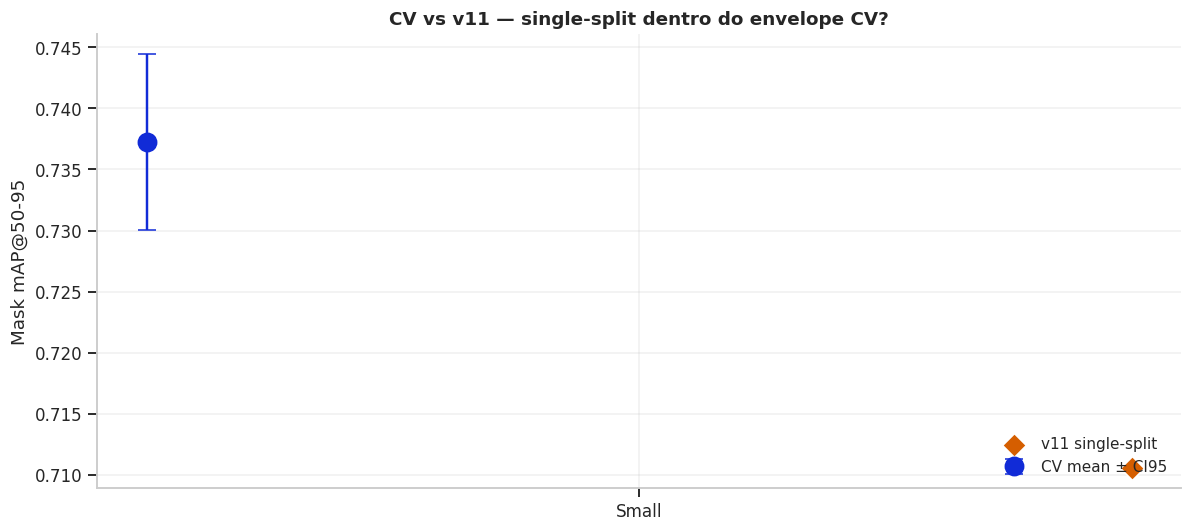

In [41]:
SINGLE_SPLIT_REF = {
    # Caminho para os logs do treino single-split (mesmo formato do compare_models.ipynb).
    "label":   "v11",
    "log_dir": BASE_DIR / "logs" / "train_isic_2018_task_1_v11",
    "model_dirs": {
        "Nano":   "yolo26_nano_ft_isic_2018_v11",
        "Small":  "yolo26_small_ft_isic_2018_v11",
        "Medium": "yolo26_medium_ft_isic_2018_v11",
        "Large":  "yolo26_large_ft_isic_2018_v11",
        "XLarge": "yolo26_xlarge_ft_isic_2018_v11",
    },
}


def _read_single_metric(rdir: Path) -> dict:
    out = {"map5095_m": np.nan, "map50_m": np.nan, "f1_m": np.nan,
           "precision_m": np.nan, "recall_m": np.nan, "best_epoch": np.nan}
    rcsv = rdir / "results.csv"
    if not rcsv.exists():
        return out
    df = pd.read_csv(rcsv)
    df.columns = [c.strip() for c in df.columns]
    if "metrics/mAP50-95(M)" not in df:
        return out
    bi = df["metrics/mAP50-95(M)"].idxmax()
    best = df.loc[bi]
    p_m = best.get("metrics/precision(M)", np.nan)
    r_m = best.get("metrics/recall(M)",    np.nan)
    f1_m = (2 * p_m * r_m / (p_m + r_m)) if (np.isfinite(p_m) and np.isfinite(r_m)
                                              and (p_m + r_m) > 0) else np.nan
    out.update({
        "map5095_m":  float(best.get("metrics/mAP50-95(M)", np.nan)),
        "map50_m":    float(best.get("metrics/mAP50(M)",    np.nan)),
        "f1_m":       float(f1_m),
        "precision_m": float(p_m),
        "recall_m":    float(r_m),
        "best_epoch":  int(best.get("epoch", -1)) if np.isfinite(best.get("epoch", np.nan)) else np.nan,
    })
    return out


rows_cmp = []
for m in MODELS_PRESENT:
    if m not in SINGLE_SPLIT_REF["model_dirs"]:
        continue
    ss_dir = SINGLE_SPLIT_REF["log_dir"] / SINGLE_SPLIT_REF["model_dirs"][m]
    ss = _read_single_metric(ss_dir)
    # CV referente — usa o champion por scale
    cv_sub = (df_long[df_long["Model"] == m]
              .sort_values("map5095_m_mean", ascending=False))
    if cv_sub.empty:
        continue
    cv = cv_sub.iloc[0]
    cv_lo = cv["map5095_m_mean"] - cv["map5095_m_ci95"]
    cv_hi = cv["map5095_m_mean"] + cv["map5095_m_ci95"]
    within = (np.isfinite(ss["map5095_m"]) and cv_lo <= ss["map5095_m"] <= cv_hi)
    rows_cmp.append({
        "Model": m,
        "CV version": cv["Version"],
        "CV mean (Mask mAP@50-95)":   cv["map5095_m_mean"],
        "CV CI95 half":               cv["map5095_m_ci95"],
        "CV CI95 lo":                 cv_lo,
        "CV CI95 hi":                 cv_hi,
        f"{SINGLE_SPLIT_REF['label']} (single-split)": ss["map5095_m"],
        "Δ (single − CV mean)":       (ss["map5095_m"] - cv["map5095_m_mean"]
                                       if np.isfinite(ss["map5095_m"]) else np.nan),
        "Within CV CI95?":            "✓" if within else ("✗" if np.isfinite(ss["map5095_m"]) else "—"),
    })

ss_label = SINGLE_SPLIT_REF["label"]
ss_col = f"{ss_label} (single-split)"
any_ss_finite = any(np.isfinite(r.get(ss_col, np.nan)) for r in rows_cmp)

if not rows_cmp:
    print(f"[skip] não encontrei {ss_label} em "
          f"{SINGLE_SPLIT_REF['log_dir']}. Ajuste SINGLE_SPLIT_REF acima.")
elif not any_ss_finite:
    print(f"[skip] {ss_label} configurado mas nenhum results.csv legível em "
          f"{SINGLE_SPLIT_REF['log_dir']}. Ajuste SINGLE_SPLIT_REF para apontar "
          "para uma versão single-split com resultados disponíveis.")
else:
    cmp_df = pd.DataFrame(rows_cmp).set_index("Model").reindex(MODELS_PRESENT)
    display(Markdown(f"### CV (este notebook) vs `{SINGLE_SPLIT_REF['label']}` (single-split)"))
    display(cmp_df.style.format({
        "CV mean (Mask mAP@50-95)":   "{:.4f}",
        "CV CI95 half":               "{:.4f}",
        "CV CI95 lo":                 "{:.4f}",
        "CV CI95 hi":                 "{:.4f}",
        ss_col: "{:.4f}",
        "Δ (single − CV mean)":       "{:+.4f}",
    }, na_rep="—"))

    # Visualização
    fig, ax = plt.subplots(figsize=(11, 5.0))
    ms = [m for m in MODELS_PRESENT if m in cmp_df.index and
          np.isfinite(cmp_df.loc[m, "CV mean (Mask mAP@50-95)"])]
    x = np.arange(len(ms))
    cv_means = [cmp_df.loc[m, "CV mean (Mask mAP@50-95)"] for m in ms]
    cv_ci    = [cmp_df.loc[m, "CV CI95 half"]             for m in ms]
    ss_vals  = [cmp_df.loc[m, ss_col] for m in ms]

    ax.errorbar(x - 0.10, cv_means, yerr=cv_ci, fmt="o", color="#112BD7",
                ms=12, capsize=6, lw=1.6, label="CV mean ± CI95")
    ax.scatter(x + 0.10, ss_vals, marker="D", color="#D55E00", s=120,
               edgecolor="white", lw=1.0, zorder=3,
               label=f"{ss_label} single-split")
    ax.set_xticks(x); ax.set_xticklabels(ms)
    ax.set_ylabel("Mask mAP@50-95")
    ax.set_title(f"CV vs {ss_label} — single-split dentro do envelope CV?")
    ax.legend(loc="lower right", fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 18. Export — CSV consolidado (todos os folds + summary)

In [42]:
# (a) Long per-fold (uma linha por fold) ---------------------------------------
export_folds = df_folds.copy()
export_folds = export_folds[[
    "Version", "Model", "fold", "best_epoch",
    "map5095_m", "map50_m", "f1_m", "precision_m", "recall_m",
    "map5095_b", "map50_b", "f1_b", "precision_b", "recall_b",
] if all(c in df_folds.columns for c in
         ["fold", "best_epoch", "map5095_m"])
   else [c for c in df_folds.columns if c not in ()]]

out_folds = BASE_DIR / "logs" / "cv" / "compare_models_cv_per_fold.csv"
out_folds.parent.mkdir(parents=True, exist_ok=True)
export_folds.to_csv(out_folds, index=False)
print(f"Per-fold:  {out_folds}  ({len(export_folds)} linhas)")


# (b) Summary (uma linha por combinação) --------------------------------------
summary_cols_keep = [
    "Version", "Model", "Params (M)", "GFLOPs", "k_folds",
    "map5095_m_mean", "map5095_m_std",   "map5095_m_ci95", "map5095_m_cv",
    "map50_m_mean",   "map50_m_std",     "map50_m_ci95",   "map50_m_cv",
    "f1_m_mean",      "f1_m_std",        "f1_m_ci95",      "f1_m_cv",
    "precision_m_mean", "precision_m_std", "precision_m_ci95", "precision_m_cv",
    "recall_m_mean",  "recall_m_std",    "recall_m_ci95",  "recall_m_cv",
    "map5095_b_mean", "map5095_b_std",   "map5095_b_ci95", "map5095_b_cv",
    "map50_b_mean",   "map50_b_std",     "map50_b_ci95",   "map50_b_cv",
    "f1_b_mean",      "f1_b_std",        "f1_b_ci95",      "f1_b_cv",
    "best_epoch_mean", "best_epoch_std",
    "Train time / fold (min)", "Train time total (min)",
    "Stability (avg std last10)", "Overfit gap (avg)",
    "Eps to 95% (avg)", "Eps to 99% (avg)",
]
present = [c for c in summary_cols_keep if c in df_long.columns]
export_summary = df_long[present].copy()

out_summary = BASE_DIR / "logs" / "cv" / "compare_models_cv_summary.csv"
export_summary.to_csv(out_summary, index=False)
print(f"Summary:   {out_summary}  ({len(export_summary)} linhas)")

display(Markdown(f"**Exports salvos**: `{out_folds.name}` + `{out_summary.name}` em "
                 f"`{out_summary.parent}`"))


Per-fold:  /home/antoniovinicius/projects/sandbox_yolo26/logs/cv/compare_models_cv_per_fold.csv  (5 linhas)
Summary:   /home/antoniovinicius/projects/sandbox_yolo26/logs/cv/compare_models_cv_summary.csv  (1 linhas)


**Exports salvos**: `compare_models_cv_per_fold.csv` + `compare_models_cv_summary.csv` em `/home/antoniovinicius/projects/sandbox_yolo26/logs/cv`